In [ ]:
from google.colab import files
uploaded=files.upload()

Saving accident_prediction_india.csv to accident_prediction_india (1).csv


In [ ]:
import pandas as pd
df=pd.read_csv('accident_prediction_india.csv')
print(df.shape)
df.head()

(3000, 22)


,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Road Type,Road Condition,Lighting Conditions,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details
0,Jammu and Kashmir,Unknown,2021,May,Monday,1:46,Serious,5,Cycle,0,...,National Highway,Wet,Dark,Signs,61,66,Male,NaN,Yes,Curve
1,Uttar Pradesh,Lucknow,2018,January,Wednesday,21:30,Minor,5,Truck,5,...,Urban Road,Dry,Dusk,Signs,92,60,Male,NaN,Yes,Straight Road
2,Chhattisgarh,Unknown,2023,May,Wednesday,5:37,Minor,5,Pedestrian,6,...,National Highway,Under Construction,Dawn,Signs,120,26,Female,NaN,No,Bridge
3,Uttar Pradesh,Lucknow,2020,June,Saturday,0:31,Minor,3,Bus,10,...,State Highway,Dry,Dark,Signals,76,34,Female,Valid,Yes,Straight Road
4,Sikkim,Unknown,2021,August,Thursday,11:21,Minor,5,Cycle,7,...,Urban Road,Wet,Dusk,Signs,115,30,Male,NaN,No,Intersection


In [ ]:
import sqlite3

#Create SQLite database and load data
conn=sqlite3.connect('accidents.db')
df.to_sql('accidents',conn,if_exists='replace',index=False)

#Test query-check total records
query="SELECT COUNT(*)as total_records FROM accidents"
result=pd.read_sql(query, conn)
print(result)

   total_records
0           3000


In [ ]:
q2="""
SELECT Weather_Conditions, COUNT(*)as fatal_count
FROM accidents
WHERE Accident_Severity='Fatal'
GROUP BY Weather_Conditions
ORDER BY fatal_count DESC
"""
result2=pd.read_sql(query2,conn)
print(result2)

  Weather Conditions  fatal_count
0             Stormy          203
1               Hazy          200
2              Rainy          197
3              Foggy          195
4              Clear          190


In [ ]:
print(df.columns.tolist())

In [ ]:
query2="""
SELECT "Weather Conditions", COUNT(*)as fatal_count
FROM accidents
WHERE "Accident Severity"='Fatal'
GROUP BY "Weather Conditions"
ORDER BY fatal_count DESC
"""
result2=pd.read_sql(query2,conn)
print(result2)

  Weather Conditions  fatal_count
0             Stormy          203
1               Hazy          200
2              Rainy          197
3              Foggy          195
4              Clear          190


In [ ]:
query3 = """
SELECT "Time of Day", COUNT(*) as fatal_count
FROM accidents
WHERE "Accident Severity" = 'Fatal'
GROUP BY "Time of Day"
ORDER BY fatal_count DESC
LIMIT 10
"""
result3 = pd.read_sql(query3, conn)
print(result3)

  Time of Day  fatal_count
0       16:38            5
1       21:52            4
2       20:31            4
3       17:55            4
4        15:1            4
5       13:27            4
6       12:50            4
7        0:49            4
8        9:22            3
9         8:8            3


In [ ]:
query4 = """
SELECT CAST(SUBSTR("Time of Day", 1, INSTR("Time of Day", ':') - 1) AS INTEGER) as hour,
COUNT(*) as fatal_count
FROM accidents
WHERE "Accident Severity" = 'Fatal'
GROUP BY hour
ORDER BY fatal_count DESC
"""
result4 = pd.read_sql(query4, conn)
print(result4)

    hour  fatal_count
0      8           56
1      7           52
2     22           47
3      3           47
4     21           46
5      2           46
6     11           44
7     16           43
8     13           41
9     12           41
10     9           41
11    23           40
12    19           40
13    17           40
14     1           40
15     0           40
16    14           38
17    10           38
18     6           38
19     5           38
20    20           37
21     4           32
22    15           31
23    18           29


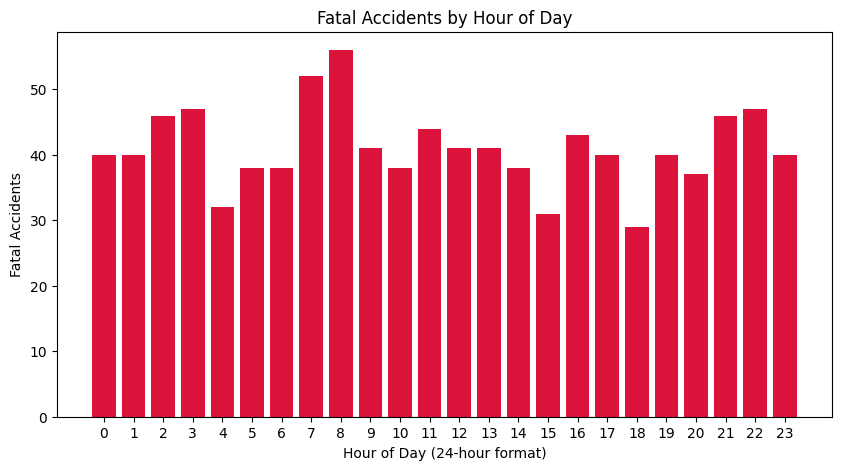

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(result4['hour'], result4['fatal_count'], color='crimson')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Fatal Accidents')
plt.title('Fatal Accidents by Hour of Day')
plt.xticks(range(0,24))
plt.show()

In [ ]:
query5 = """
SELECT "State Name", COUNT(*) as fatal_count
FROM accidents
WHERE "Accident Severity" = 'Fatal'
GROUP BY "State Name"
ORDER BY fatal_count DESC
LIMIT 10
"""
result5 = pd.read_sql(query5, conn)
print(result5)


          State Name  fatal_count
0             Kerala           40
1                Goa           40
2           Nagaland           39
3         Tamil Nadu           38
4        Uttarakhand           37
5        West Bengal           36
6         Puducherry           35
7        Maharashtra           35
8  Jammu and Kashmir           35
9            Mizoram           34


In [ ]:
query6 = """
SELECT "Road Type", COUNT(*) as fatal_count
FROM accidents
WHERE "Accident Severity" = 'Fatal'
GROUP BY "Road Type"
ORDER BY fatal_count DESC
"""
result6 = pd.read_sql(query6, conn)
print(result6)

          Road Type  fatal_count
0     State Highway          261
1        Urban Road          254
2  National Highway          242
3      Village Road          228


In [ ]:
query7 = """
SELECT "Vehicle Type Involved", COUNT(*) as fatal_count
FROM accidents
WHERE "Accident Severity" = 'Fatal'
GROUP BY "Vehicle Type Involved"
ORDER BY fatal_count DESC
"""
result7 = pd.read_sql(query7, conn)
print(result7)

  Vehicle Type Involved  fatal_count
0                 Cycle          167
1                   Bus          167
2            Pedestrian          134
3                 Truck          132
4           Two-Wheeler          131
5         Auto-Rickshaw          129
6                   Car          125


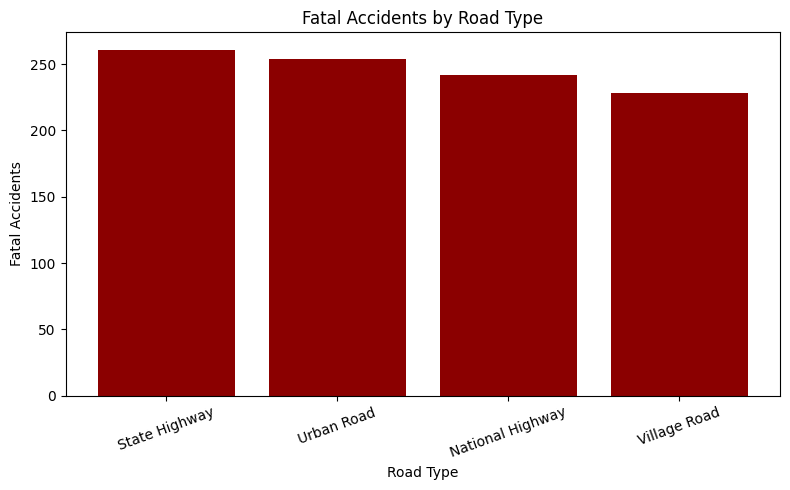

In [ ]:
import matplotlib.pyplot as plt

# Road Type chart
plt.figure(figsize=(8,5))
plt.bar(result6['Road Type'], result6['fatal_count'], color='#8b0000')
plt.title('Fatal Accidents by Road Type')
plt.xlabel('Road Type')
plt.ylabel('Fatal Accidents')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('fatal_by_road_type.png')
plt.show()

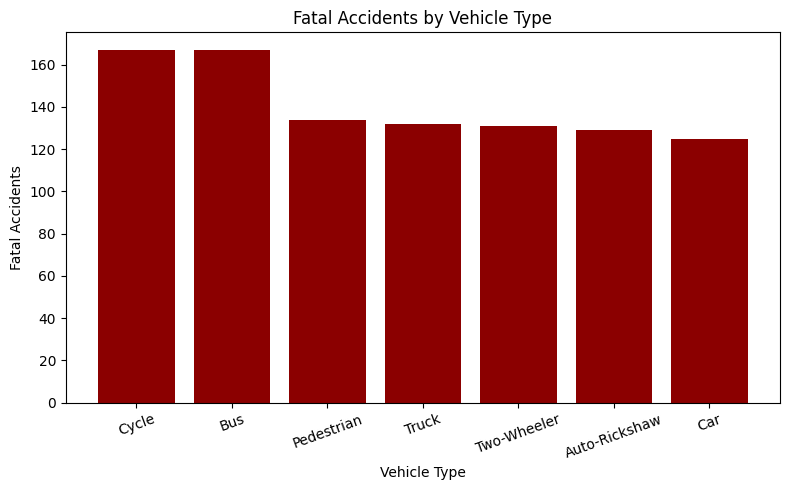

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(result7['Vehicle Type Involved'], result7['fatal_count'], color='#8b0000')
plt.title('Fatal Accidents by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Fatal Accidents')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('fatal_by_vehicle_type.png')
plt.show()

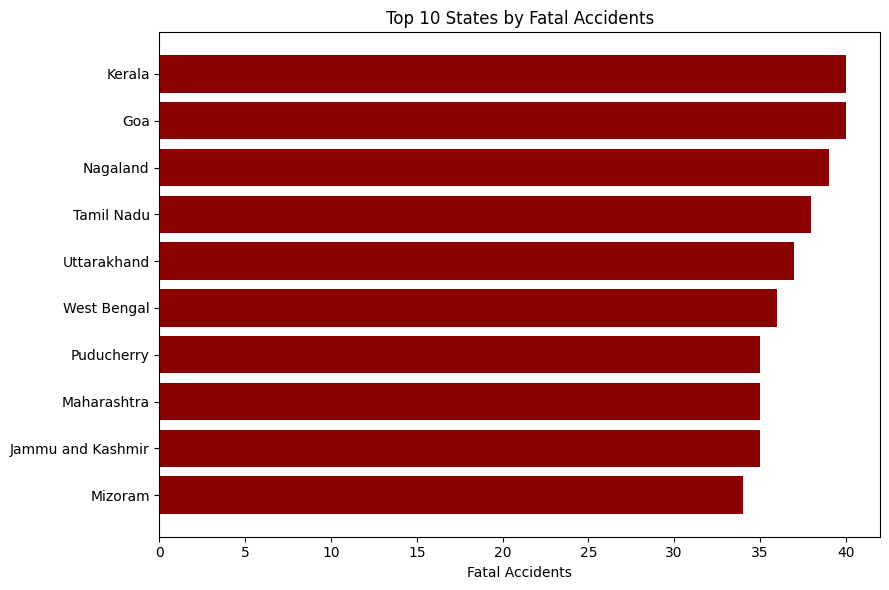

In [ ]:
plt.figure(figsize=(9,6))
plt.barh(result5['State Name'], result5['fatal_count'], color='#8b0000')
plt.title('Top 10 States by Fatal Accidents')
plt.xlabel('Fatal Accidents')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('fatal_by_state_raw_vs_normalized.png')
plt.show()

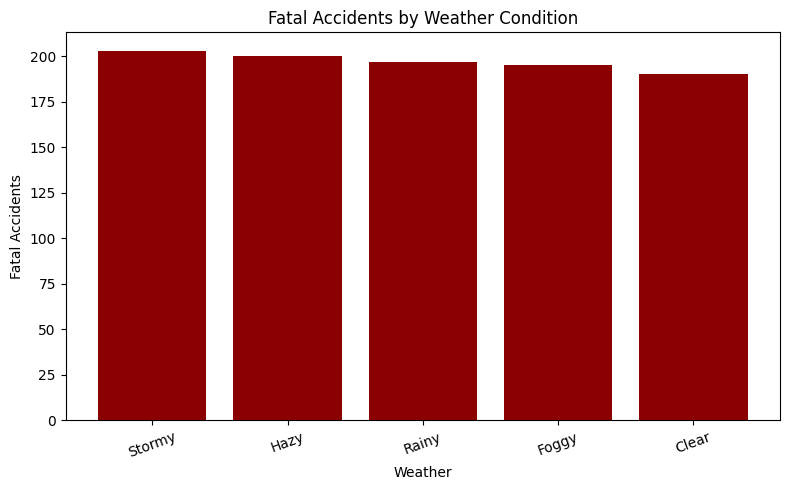

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(result2['Weather Conditions'], result2['fatal_count'], color='#8b0000')
plt.title('Fatal Accidents by Weather Condition')
plt.xlabel('Weather')
plt.ylabel('Fatal Accidents')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('fatal_by_weather.png')
plt.show()